In [60]:
import pandas as pd

clean = pd.read_csv("/content/NHANES_cleaned_master.csv")

print("Dataset loaded successfully!")
print("Shape:", clean.shape)
print("\nColumns:")
print(clean.columns.tolist())

Dataset loaded successfully!
Shape: (11933, 28)

Columns:
['SEQN', 'Age', 'Sex', 'BMI', 'Waist', 'Systolic_BP', 'Diastolic_BP', 'Hypertension', 'HDL', 'Total_Cholesterol', 'Glucose', 'HbA1c', 'Creatinine', 'BUN', 'Diabetes_Status', 'Heart_Failure', 'Coronary_Heart_Disease', 'Angina', 'Heart_Attack', 'Kidney_Disease', 'Dialysis', 'Prediabetes_Status', 'Kidney_Disease_History', 'Dialysis_Status', 'eGFR', 'CKD', 'Diabetes', 'Heart_Disease']


In [61]:
for column in ["Diabetes", "Heart_Disease", "CKD"]:
    print("\n" + "=" * 40)
    print(column)
    print(clean[column].value_counts(dropna=False))


Diabetes
Diabetes
0.0    10371
1.0     1081
NaN      481
Name: count, dtype: int64

Heart_Disease
Heart_Disease
0.0    7025
NaN    4163
1.0     745
Name: count, dtype: int64

CKD
CKD
NaN    6377
0.0    4881
1.0     675
Name: count, dtype: int64


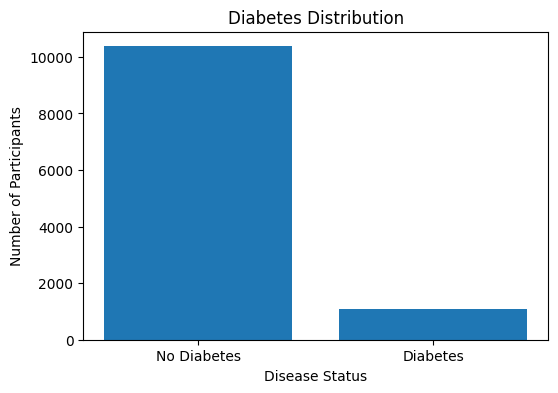

In [62]:
import matplotlib.pyplot as plt

diabetes_counts = clean["Diabetes"].value_counts(dropna=True)

plt.figure(figsize=(6, 4))

plt.bar(
    ["No Diabetes", "Diabetes"],
    [
        diabetes_counts.get(0, 0),
        diabetes_counts.get(1, 0)
    ]
)

plt.title("Diabetes Distribution")
plt.xlabel("Disease Status")
plt.ylabel("Number of Participants")

plt.show()

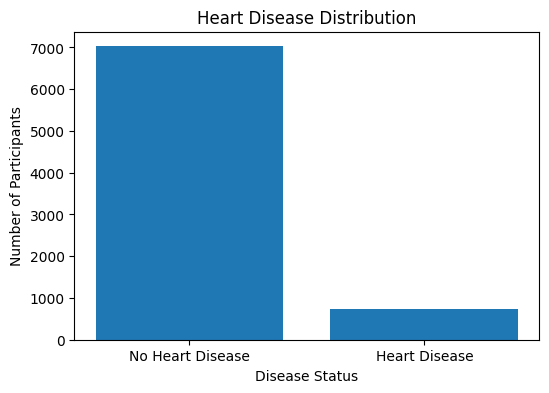

In [63]:
heart_counts = clean["Heart_Disease"].value_counts(dropna=True)

plt.figure(figsize=(6, 4))

plt.bar(
    ["No Heart Disease", "Heart Disease"],
    [
        heart_counts.get(0, 0),
        heart_counts.get(1, 0)
    ]
)

plt.title("Heart Disease Distribution")
plt.xlabel("Disease Status")
plt.ylabel("Number of Participants")

plt.show()

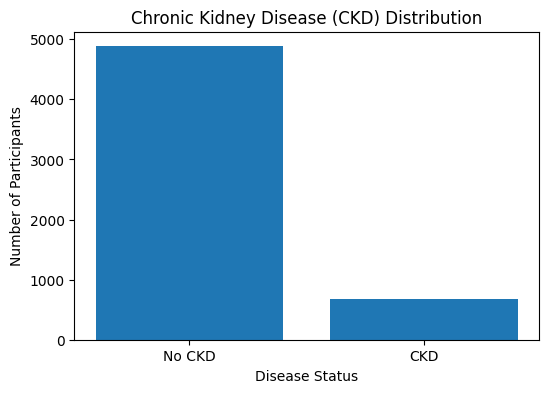

In [64]:
ckd_counts = clean["CKD"].value_counts(dropna=True)

plt.figure(figsize=(6, 4))

plt.bar(
    ["No CKD", "CKD"],
    [
        ckd_counts.get(0, 0),
        ckd_counts.get(1, 0)
    ]
)

plt.title("Chronic Kidney Disease (CKD) Distribution")
plt.xlabel("Disease Status")
plt.ylabel("Number of Participants")

plt.show()

In [65]:
overview = pd.DataFrame({
    "Dataset": [
        "NHANES Cleaned Master Dataset"
    ],
    "Participants": [
        len(clean)
    ],
    "Clinical Variables": [
        len(clean.columns)
    ],
    "Purpose": [
        "Integrated dataset for diabetes, heart disease and CKD prediction"
    ]
})

overview

,Dataset,Participants,Clinical Variables,Purpose
0,NHANES Cleaned Master Dataset,11933,28,"Integrated dataset for diabetes, heart disease..."


In [66]:
categories = pd.DataFrame({
    "Category": [
        "Demographic Information",
        "Body Measurements",
        "Vital Signs",
        "Cholesterol Indicators",
        "Diabetes Indicators",
        "Kidney Indicators",
        "Disease Targets"
    ],
    "Variables": [
        "Age, Sex",
        "BMI, Waist",
        "Systolic BP, Diastolic BP",
        "HDL, Total Cholesterol",
        "Glucose, HbA1c",
        "Creatinine, BUN, eGFR",
        "Diabetes, Heart Disease, CKD"
    ]
})

categories

,Category,Variables
0,Demographic Information,"Age, Sex"
1,Body Measurements,"BMI, Waist"
2,Vital Signs,"Systolic BP, Diastolic BP"
3,Cholesterol Indicators,"HDL, Total Cholesterol"
4,Diabetes Indicators,"Glucose, HbA1c"
5,Kidney Indicators,"Creatinine, BUN, eGFR"
6,Disease Targets,"Diabetes, Heart Disease, CKD"


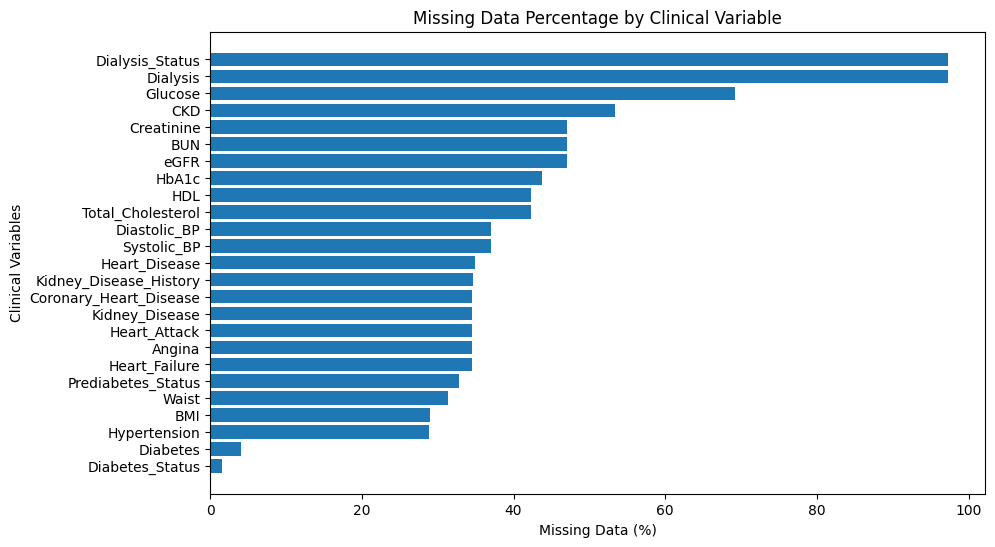

In [67]:
missing = pd.DataFrame({
    "Missing_Percent": clean.isna().mean() * 100
})

missing_plot = missing[
    missing["Missing_Percent"] > 0
].sort_values(
    "Missing_Percent",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    missing_plot.index,
    missing_plot["Missing_Percent"]
)

plt.xlabel("Missing Data (%)")
plt.ylabel("Clinical Variables")
plt.title("Missing Data Percentage by Clinical Variable")

plt.gca().invert_yaxis()

plt.show()

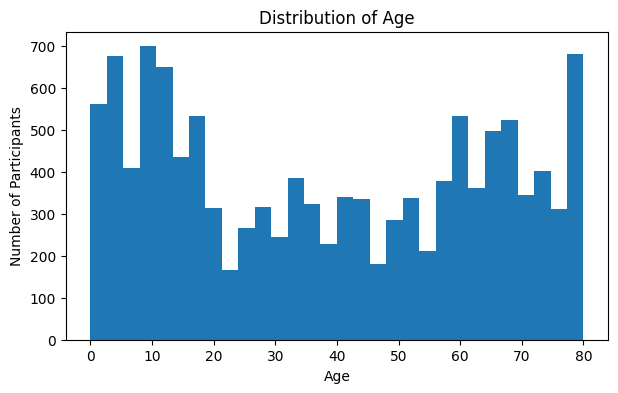

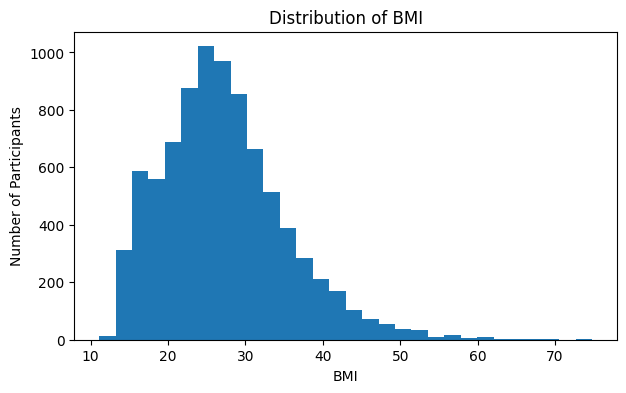

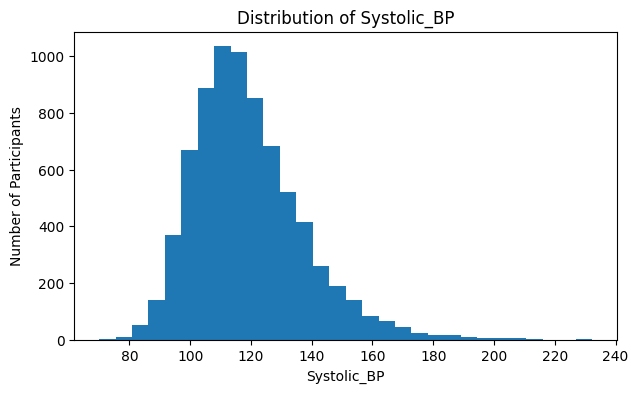

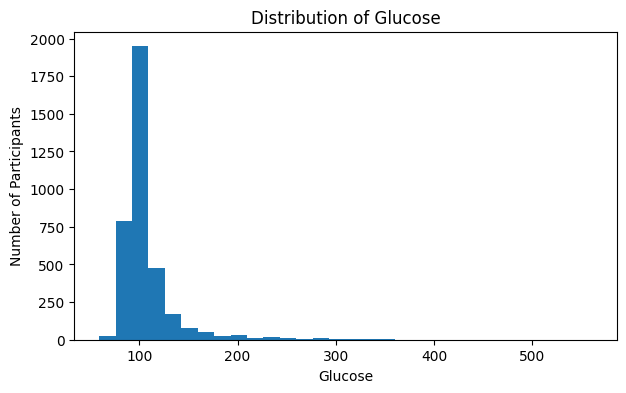

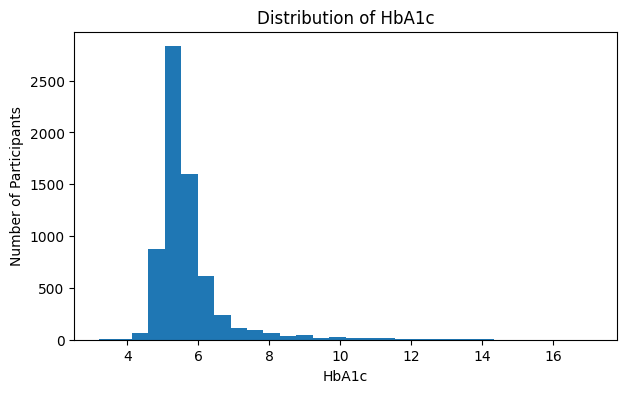

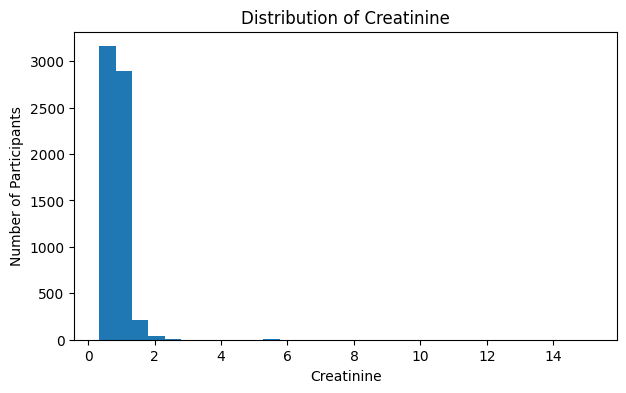

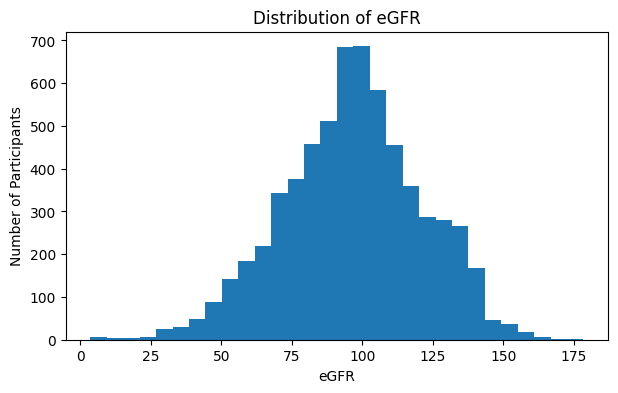

In [68]:
features = [
    "Age",
    "BMI",
    "Systolic_BP",
    "Glucose",
    "HbA1c",
    "Creatinine",
    "eGFR"
]

for feature in features:

    if feature in clean.columns:

        plt.figure(figsize=(7, 4))

        plt.hist(
            clean[feature].dropna(),
            bins=30
        )

        plt.title(f"Distribution of {feature}")
        plt.xlabel(feature)
        plt.ylabel("Number of Participants")

        plt.show()